# WTA Match Predictor

A model that predicts the winner of WTA (women's professional tennis) matches using only what's known before play starts: each player's ranking, age, height, and recent form.

Data: Jeff Sackmann's public tennis database (CC BY-NC-SA 4.0).

Pipeline:
1. Pull the match data from Kaggle.
2. Filter to the women's tour and the pre-match columns.
3. Reshape each match into a neutral player 1 vs player 2 format, so the label isn't baked into the inputs.
4. Build the features: ranking gap, recent form, surface win rate, head to head.
5. Train a logistic regression and score it against a ranking baseline using AUC, log loss, and calibration.

## Step 1. Setup and data download

Downloads the dataset from Kaggle. You'll need a free Kaggle account and an API token: in your Kaggle account settings, open the API section and create one, which downloads `kaggle.json`. Run this cell and upload that file when prompted.

In [1]:
# Upload your kaggle.json token file when the button appears
from google.colab import files
files.upload()

# Configure Kaggle using the token
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
!pip install -q kaggle

# Download the tennis dataset and unzip it into a folder called tennis_data
!kaggle datasets download -d taylorbrownlow/atpwta-tennis-data --unzip -p tennis_data

print("Download complete")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/taylorbrownlow/atpwta-tennis-data
License(s): CC-BY-NC-SA-4.0
100% 16.2M/16.2M [00:00<00:00, 89.9MB/s]

Download complete


## Step 2. Load and filter to the WTA

The file holds both tours, tagged by a `league` column. We keep the WTA rows, take the columns that describe each player before the match, and drop any match missing a ranking for either side.

In [2]:
import pandas as pd

# Load the full match file
all_matches = pd.read_csv("tennis_data/KaggleMatches.csv", low_memory=False)

# Keep only the women's tour
wta = all_matches[all_matches["league"] == "wta"].copy()

# Keep the columns that describe each player before the match
columns_to_keep = [
    "tourney_date", "surface",
    "winner_name", "winner_rank", "winner_age", "winner_ht",
    "loser_name", "loser_rank", "loser_age", "loser_ht",
]
wta = wta[columns_to_keep]

# A ranking for both players is required, so drop matches missing either one
wta = wta.dropna(subset=["winner_rank", "loser_rank"])

print("WTA matches ready:", len(wta))

WTA matches ready: 92129


## Step 3. Reshape into neutral matchups

The raw data labels every row as winner and loser, so the answer is baked into the column order. Train on that directly and the model just learns that the winner column wins, which is useless. So we randomize it: each match becomes player 1 vs player 2, and for a random half of the matches we swap who comes first. The target `p1_won` is 1 if player 1 won, 0 otherwise. After the swap, player 1 should win about half the time, and the printed rate near 0.50 confirms the labels are balanced and column order carries no signal.

In [3]:
import numpy as np

# Use a fixed random seed so the result is the same every run
np.random.seed(42)

# Choose about half the matches at random to swap
swap = np.random.rand(len(wta)) < 0.5

# Build the neutral table.
# Where swap is False, player one is the winner.
# Where swap is True, player one is the loser.
matches = pd.DataFrame({
    "tourney_date": wta["tourney_date"].values,
    "surface": wta["surface"].values,
    "p1_name": np.where(swap, wta["loser_name"], wta["winner_name"]),
    "p1_rank": np.where(swap, wta["loser_rank"], wta["winner_rank"]),
    "p1_age": np.where(swap, wta["loser_age"], wta["winner_age"]),
    "p1_ht": np.where(swap, wta["loser_ht"], wta["winner_ht"]),
    "p2_name": np.where(swap, wta["winner_name"], wta["loser_name"]),
    "p2_rank": np.where(swap, wta["winner_rank"], wta["loser_rank"]),
    "p2_age": np.where(swap, wta["winner_age"], wta["loser_age"]),
    "p2_ht": np.where(swap, wta["winner_ht"], wta["loser_ht"]),
    "p1_won": np.where(swap, 0, 1),
})

# Sort by date so we can later train on the past and test on the future
matches = matches.sort_values("tourney_date").reset_index(drop=True)

print("Matches:", len(matches))
print("Player one win rate:", round(matches["p1_won"].mean(), 3),
      "(near 0.50 means the setup is fair)")

Matches: 92129
Player one win rate: 0.501 (near 0.50 means the setup is fair)


## Step 4. Build the features

Six features, each a player 1 minus player 2 difference:

1. Log ranking gap. Rank differences aren't linear, the gap between #1 and #50 matters far more than #200 to #250, so we take logs before differencing.
2. Recent form: win rate over each player's last 20 matches. Catches hot and cold streaks and injury comebacks that a stale ranking misses.
3. Surface win rate: win rate on the current surface (hard, clay, grass) so far. Some players are far better on clay than grass, which ranking hides.
4. Head to head: player 1's edge in their prior meetings. Zero for most pairs, since most have never played.
5. Age gap.
6. Height gap.

Form, surface win rate, and head to head are computed in one pass in date order, with each result recorded only after it's read, so a match never sees its own outcome. That no-lookahead detail is what makes the form numbers trustworthy.

In [4]:
from collections import defaultdict, deque

# Ranking gap on a logarithmic scale.
# A lower ranking number means a stronger player, so a negative value favors player one.
matches["log_rank_diff"] = np.log(matches["p1_rank"]) - np.log(matches["p2_rank"])

# Age gap and height gap. Missing values become 0, meaning no known difference.
matches["age_diff"] = (matches["p1_age"] - matches["p2_age"]).fillna(0)
matches["ht_diff"] = (matches["p1_ht"] - matches["p2_ht"]).fillna(0)

# Running features, all measured strictly before the current match:
#   recent form        each player's win rate over her last 20 matches
#   surface win rate   each player's win rate on the current surface so far
#   head to head       player one's edge in past meetings between the two
recent_results = defaultdict(lambda: deque(maxlen=20))   # player -> recent wins and losses
surface_wins = defaultdict(int)                          # (player, surface) -> wins
surface_played = defaultdict(int)                        # (player, surface) -> matches played
h2h_wins = defaultdict(lambda: defaultdict(int))         # h2h_wins[a][b] = times a beat b

p1_form, p2_form = [], []
p1_surface, p2_surface = [], []
h2h_edge = []

for match in matches.itertuples():
    # --- read the history (this never includes the current match) ---
    history_p1 = recent_results[match.p1_name]
    history_p2 = recent_results[match.p2_name]
    p1_form.append(np.mean(history_p1) if history_p1 else 0.5)
    p2_form.append(np.mean(history_p2) if history_p2 else 0.5)

    surface = match.surface
    known_surface = isinstance(surface, str) and surface != ""
    if known_surface:
        played_1 = surface_played[(match.p1_name, surface)]
        played_2 = surface_played[(match.p2_name, surface)]
        rate_1 = surface_wins[(match.p1_name, surface)] / played_1 if played_1 else 0.5
        rate_2 = surface_wins[(match.p2_name, surface)] / played_2 if played_2 else 0.5
    else:
        rate_1 = rate_2 = 0.5
    p1_surface.append(rate_1)
    p2_surface.append(rate_2)

    p1_beat_p2 = h2h_wins[match.p1_name][match.p2_name]
    p2_beat_p1 = h2h_wins[match.p2_name][match.p1_name]
    meetings = p1_beat_p2 + p2_beat_p1
    h2h_edge.append((p1_beat_p2 / meetings - 0.5) if meetings else 0.0)

    # --- record this result AFTER reading, so the current match never leaks ---
    recent_results[match.p1_name].append(match.p1_won)
    recent_results[match.p2_name].append(1 - match.p1_won)

    if known_surface:
        surface_played[(match.p1_name, surface)] += 1
        surface_played[(match.p2_name, surface)] += 1
        winner_name = match.p1_name if match.p1_won == 1 else match.p2_name
        surface_wins[(winner_name, surface)] += 1

    if match.p1_won == 1:
        h2h_wins[match.p1_name][match.p2_name] += 1
    else:
        h2h_wins[match.p2_name][match.p1_name] += 1

matches["form_diff"] = np.array(p1_form) - np.array(p2_form)
matches["surface_wr_diff"] = np.array(p1_surface) - np.array(p2_surface)
matches["h2h_diff"] = h2h_edge

print("Features ready")

Features ready


## Step 5. Train and evaluate

We split by time: train on the oldest 80% of matches, test on the most recent 20%. That's more realistic than a random split, since in practice you predict forward, not backward.

The features run through a standard scaler first. It doesn't change the predictions, but it puts every feature on the same footing so the weights can be compared directly (otherwise we'd be comparing log ranking points to a 0 to 1 form share to centimeters). The scaler is fit on the training rows only, so nothing from the test set leaks in.

Three things to compare: a baseline that always picks the higher ranked player, a ranking-only model, and the full six-feature model. And three metrics: accuracy (share of correct picks), AUC (how well the model ranks matchups by win likelihood, higher better), and log loss (quality of the predicted probabilities, lower better). Accuracy is the weakest signal here, since ranking alone already calls most matches right, so the real differences show up in AUC and log loss.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Split by time: oldest 80 percent to train, newest 20 percent to test
split_point = int(len(matches) * 0.8)
y_train = matches["p1_won"].iloc[:split_point]
y_test = matches["p1_won"].iloc[split_point:]

# The full feature set, defined once so the charts below can reuse it
FEATURES = ["log_rank_diff", "form_diff", "surface_wr_diff", "h2h_diff", "age_diff", "ht_diff"]

def train_and_score(feature_names, label):
    X = matches[feature_names]
    # StandardScaler is fit inside the pipeline on the training rows only,
    # so the test set never influences the scaling. No leakage.
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    model.fit(X.iloc[:split_point], y_train)
    probabilities = model.predict_proba(X.iloc[split_point:])[:, 1]
    picks = (probabilities >= 0.5).astype(int)
    print(label)
    print("   accuracy:", round(accuracy_score(y_test, picks), 3))
    print("   AUC:     ", round(roc_auc_score(y_test, probabilities), 3))
    print("   log loss:", round(log_loss(y_test, probabilities), 3))
    print()
    return model, probabilities

# Baseline: always pick the higher ranked player (the lower ranking number)
baseline_picks = (matches["p1_rank"].iloc[split_point:] < matches["p2_rank"].iloc[split_point:]).astype(int)
print("Baseline, always pick the higher ranked player")
print("   accuracy:", round(accuracy_score(y_test, baseline_picks), 3))
print()

# Model one: ranking only
rank_model, rank_probabilities = train_and_score(["log_rank_diff"], "Model using ranking only")

# Model two: the full feature set
final_model, final_probabilities = train_and_score(
    FEATURES, "Model using ranking, form, surface, head to head, age, and height"
)

# Show what the model learned. Because the features were scaled, these weights
# sit on the same footing and can be compared. A larger size means a bigger
# effect on the predicted chance that player one wins.
final_logreg = final_model.named_steps["logisticregression"]
print("What the model learned (scaled weights, largest effect first):")
for name, weight in sorted(zip(FEATURES, final_logreg.coef_[0]), key=lambda pair: -abs(pair[1])):
    print("  ", name, round(weight, 4))

Baseline, always pick the higher ranked player
   accuracy: 0.639

Model using ranking only
   accuracy: 0.639
   AUC:      0.689
   log loss: 0.646

Model using ranking, form, surface, head to head, age, and height
   accuracy: 0.641
   AUC:      0.694
   log loss: 0.641

What the model learned (scaled weights, largest effect first):
   log_rank_diff -0.9968
   surface_wr_diff 0.1386
   age_diff -0.1249
   h2h_diff 0.0906
   form_diff 0.0465
   ht_diff 0.0379


## Step 5b. Visualize

Three charts: an ROC curve with both models against a random-guess diagonal (further toward the top left is better), a calibration plot that checks whether the predicted probabilities are honest (points on the diagonal mean a stated 70% chance really wins about 70% of the time), and the model's scaled feature weights.

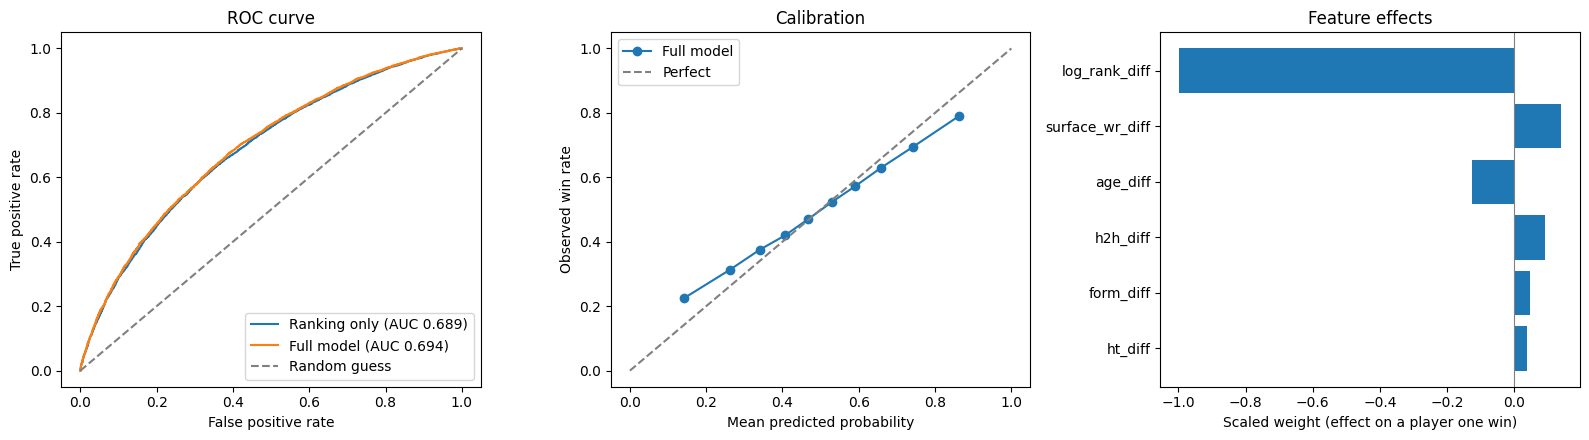

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) ROC curve: ranking only vs the full model
for probabilities, label in [(rank_probabilities, "Ranking only"),
                             (final_probabilities, "Full model")]:
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC {auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random guess")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend(loc="lower right")

# 2) Calibration: are the predicted probabilities honest?
observed, predicted = calibration_curve(y_test, final_probabilities,
                                        n_bins=10, strategy="quantile")
axes[1].plot(predicted, observed, "o-", label="Full model")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Observed win rate")
axes[1].set_title("Calibration")
axes[1].legend(loc="upper left")

# 3) Feature effects: scaled weights, so the sizes are comparable
order = np.argsort(np.abs(final_logreg.coef_[0]))
axes[2].barh(np.array(FEATURES)[order], final_logreg.coef_[0][order])
axes[2].axvline(0, color="gray", linewidth=0.8)
axes[2].set_xlabel("Scaled weight (effect on a player one win)")
axes[2].set_title("Feature effects")

plt.tight_layout()
plt.show()

## Step 6. Results

The full model edges out ranking alone on data it's never seen: AUC 0.689 to 0.694, log loss 0.646 to 0.641. Small, and that's expected, ranking already reflects a player's recent results, so there isn't much left to add. Accuracy is 0.641 against the 0.639 baseline, basically tied.

The feature weights are the more interesting read. Ranking dominates (scaled weight near -1). Of the rest, surface win rate is strongest (+0.14), which fits, clay-versus-grass specialists are real. Age comes next and is negative (-0.12): with ranking held equal, the younger player is favored slightly. Head to head adds a little (+0.09), and recent form is surprisingly weak (+0.05). That weak form weight is itself the finding, over a 20-match window form barely adds anything ranking doesn't already capture.

Accuracy looks flat against the baseline because ranking settles most matches and both get those right. The gain is in the probabilities, not the yes/no call, which is what AUC and log loss measure, and the calibration plot confirms those probabilities can be trusted. Beating a ranking baseline in tennis is genuinely hard and an active research area, so a small gain measured the right way, plus honest calibration, is a real result.

Next steps: try gradient boosting, which can model feature interactions a linear model can't; add fatigue signals like matches played in the last week; or replace the all-time surface win rate with a recent window so current form on a surface counts more than results from years ago.

## Step 7. Spot check

A few test-set matches with the model's predicted probability that player 1 wins, next to what actually happened, to eyeball that the predictions look sensible.

In [7]:
# Predicted chance that player one wins, for the test matches
test_features = matches[FEATURES].iloc[split_point:]
results = matches.iloc[split_point:].copy()
results["p1_win_probability"] = final_model.predict_proba(test_features)[:, 1]

sample = results[["p1_name", "p2_name", "p1_win_probability", "p1_won"]].head(10).copy()
sample["p1_win_probability"] = sample["p1_win_probability"].round(2)
sample

,p1_name,p2_name,p1_win_probability,p1_won
73703,Karolina Pliskova,Julia Goerges,0.60,1
73704,Kirsten Flipkens,Mona Barthel,0.42,1
73705,Caroline Garcia,Klara Koukalova,0.41,0
73706,Anastasia Pavlyuchenkova,Francesca Schiavone,0.65,1
73707,Carla Suarez Navarro,Johanna Larsson,0.74,1
73708,Elina Svitolina,Roberta Vinci,0.37,1
73709,Stefanie Voegele,Galina Voskoboeva,0.56,0
73710,Lara Arruabarrena,Karin Knapp,0.40,0
73711,Kristina Mladenovic,Simona Halep,0.34,1
73712,Andrea Petkovic,Bojana Jovanovski,0.52,1
